# General Examples

A place to keep processing or other functionality that may lie outside of the standard pipeline.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
from copy import deepcopy
import lbm_suite2p_python as lsp
import fastplotlib as fpl
import tifffile

import matplotlib as mpl
mpl.rcParams.update({
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.frameon': False,
    'figure.subplot.wspace': .01,
    'figure.subplot.hspace': .01,
    'figure.figsize': (18, 13),
    'ytick.major.left': True,
})
jet = mpl.cm.get_cmap('jet')
jet.set_bad(color='k')

fastplotlib version from git (0.4.0) and __version__ (0.5.0) don't match.


Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


## Preview Scan

### [mbo_utilities.read_scan](https://millerbrainobservatory.github.io/mbo_utilities/api/core.html#mbo_utilities.read_scan) 
reads a raw [scanimage tiff](https://millerbrainobservatory.github.io/guides/lbm_data.html#lbm-metadata) lazily.

It takes a list of filesnames ["file_1", "file_2"]:
``` python
# returns a list of 'tif' files in this directory
files = mbo.get_files("D://User_Data//animal_01//", str_contains='tif')
```

Or a [glob/wildcard](https://www.malikbrowne.com/blog/a-beginners-guide-glob-patterns/)
```python
# * matches everything after _00< including the file extensions
files = r"D://User_Data//animal_01//raw_scanimage_fname_00*"
```
And returns a `scan` object that can be used like a 4D numpy array [T, Z, X, Y]

This object takes negligible memory until it is indexed `scan[:, 0, :, :] # first z-plane`

In [8]:
scan = mbo.read_scan(r"D:\W2_DATA\kbarber\2025_03_01\mk301\green\*")
scan.shape

Detected possible escaped characters in the path. Use a raw string (r'...') or double backslashes.


(5632, 14, 448, 448)

Ignore "Draw Error: Viewport has invalid rect Rect"
It is being worked on.

Data provided and set.
Is running jupyter


RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
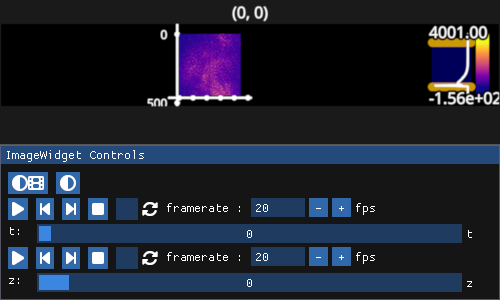

Draw error
Traceback (most recent call last):
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\rendercanvas\base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "C:\Users\RBO\repos\fastplotlib\fastplotlib\layouts\_imgui_figure.py", line 120, in _render
    self.imgui_renderer.render()
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\utils\imgui\imgui_renderer.py", line 168, in render
    render_pass.end()
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3509, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_helpers.py", line 457, in proxy_func
    raise wgpu_error
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3509, in en

In [6]:
iw = mbo.run_gui(scan)
iw.show()

In [5]:
animal_path = Path(r"D:\DATA\username\date_01\animal_01")
assembled_path = animal_path.joinpath("assembled")
save_path = animal_path.joinpath("results")
print(f"Saving raw tiffs to:        {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025-02-27\mk301\assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025-02-27\mk301\results


In [8]:
iw = fpl.ImageWidget(data=scan)

RFBOutputContext()

In [12]:
scan.shape

(5632, 14, 448, 448)

In [3]:
data = scan[50, :, :, :]
# data = np.random.randn(50, 2, 448, 448)
data.shape

(14, 448, 448)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
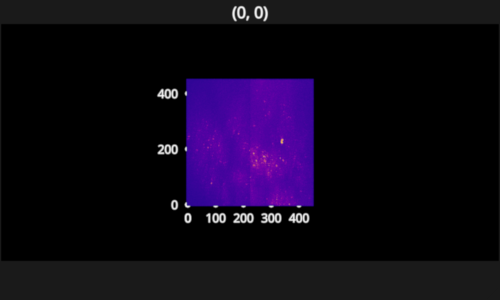

In [8]:
fig = fpl.Figure(cameras="3d")
volume = fig[0, 0].add_image_volume(data=data)
fig.show()

In [22]:
volume.cmap = "gnuplot2"

In [18]:
volume.interpolation = "linear"

In [17]:
slider

IntSlider(value=0, max=5632)

In [16]:
slider = IntSlider(0, 0, scan.shape[0])

def update_index(change):
    i = change["new"]
    volume.data = scan[i, :, :, :]

slider.observe(update_index, "value")

In [10]:
volume.world_object.world.scale_z = 15.0

In [11]:
from ipywidgets import IntSlider

In [10]:
input_files = mbo.get_files(assembled_path, str_contains='tif', max_depth=3)
input_files = [Path(x) for x in input_files]
input_files[:3]

NameError: name 'assembled_path' is not defined

In [9]:
ops_files = mbo.get_files(save_path.parent, 'ops', 4)
ops_files[:3]

NameError: name 'save_path' is not defined

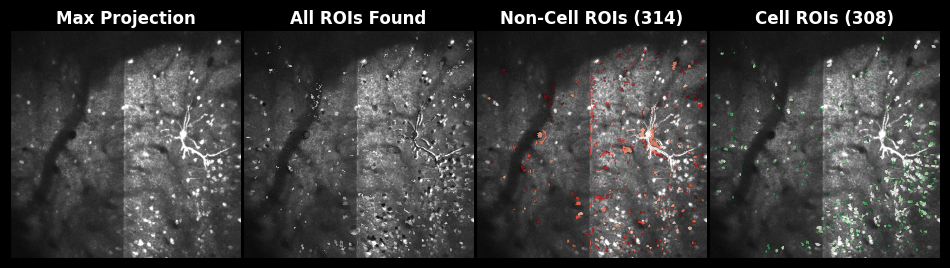

In [39]:
ops0 = lsp.load_ops(ops_files[-1])
lsp.plot_segmentation(ops0, './test_seg_overlay.png')

## Compare multiple z-planes

In [6]:
plane_6 = tifffile.memmap(input_files[5])
plane_7 = tifffile.memmap(input_files[6])

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
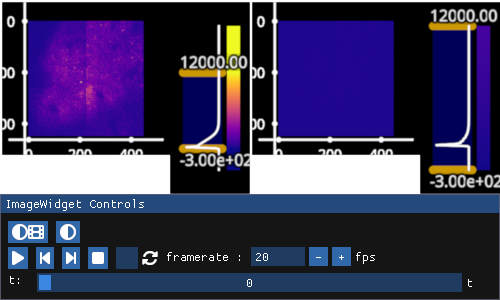

Draw error
Traceback (most recent call last):
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\fastplotlib\layouts\_imgui_figure.py", line 111, in _render
    self.imgui_renderer.render()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\utils\imgui\imgui_renderer.py", line 161, in render
    render_pass.end()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3289, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_helpers.py", line 394, in proxy_func
    raise wgpu_error  # the frame above is more interesting ↑↑
wgpu._classes.GPUValidationError: Validation Erro

In [10]:
iw = fpl.ImageWidget(data=[plane_6, plane_7])
iw.show()